# MLP Portfolio Rebalancing Pipeline

This notebook demonstrates the complete end-to-end workflow for training and evaluating MLP-based portfolio rebalancing agents.

## Pipeline Overview

1. **Data Preparation** - Download and prepare training/test data
2. **Feature Engineering** - Create 83 technical features
3. **MLP Training** - Train both Full (83 features) and Lean (37 features) models
4. **Learning Curves** - Visualize training progress
5. **Backtesting** - Evaluate on held-out test set
6. **Feature Importance** - Analyze which features drive performance
7. **Comparison** - Compare Full vs Lean MLP performance

## Setup

In [2]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

# Add parent directory to path
sys.path.append(os.path.dirname(os.getcwd()))

from core.config import *

print("✅ Setup complete")
print(f"Working directory: {os.getcwd()}")

✅ Setup complete
Working directory: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/simple/mlp


## Step 1: Data Preparation

Download historical price data and create train/test split with proper temporal separation.

In [3]:
# Choose your mode: True for EXPANDED (175 features), False for SIMPLE (83 features)
USE_EXPANDED_MODE = True  # Set this to True if you want expanded features

# Get the correct data paths based on mode
data_paths = get_data_paths(expanded_mode=USE_EXPANDED_MODE)
RAW_DATA_TRAIN_FILE = data_paths['train']
TEST_SET_FILE = data_paths['test']

mode_name = "EXPANDED" if USE_EXPANDED_MODE else "SIMPLE"

# Check if data already exists
if os.path.exists(RAW_DATA_TRAIN_FILE) and os.path.exists(TEST_SET_FILE):
    print(f"✅ Data files already exist ({mode_name} mode)")
    print(f"   Train data: {RAW_DATA_TRAIN_FILE}")
    print(f"   Test data: {TEST_SET_FILE}")
else:
    print(f"📥 Downloading data ({mode_name} mode)...")
    if USE_EXPANDED_MODE:
        %run ../core/data_eng_expanded.py
    else:
        %run ../core/data_eng_simple.py

✅ Data files already exist (EXPANDED mode)
   Train data: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/simple/data/expanded/raw_data_train.csv
   Test data: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/simple/data/expanded/test_set_NEVER_TOUCH.csv


In [4]:
# Load and inspect the data
# Note: Make sure you ran cell 4 first to set the correct paths!
# Re-fetch paths to ensure we're using the correct mode
if 'USE_EXPANDED_MODE' not in locals():
    USE_EXPANDED_MODE = True  # Default to expanded mode
data_paths = get_data_paths(expanded_mode=USE_EXPANDED_MODE)
RAW_DATA_TRAIN_FILE = data_paths['train']
TEST_SET_FILE = data_paths['test']
mode_name = "EXPANDED" if USE_EXPANDED_MODE else "SIMPLE"

train_data = pd.read_csv(RAW_DATA_TRAIN_FILE, index_col=0, parse_dates=True)
test_data = pd.read_csv(TEST_SET_FILE, index_col=0, parse_dates=True)

print(f"\n📊 DATA SUMMARY ({mode_name} MODE)")
print("=" * 60)
print(f"Train period: {train_data.index[0]} to {train_data.index[-1]}")
print(f"Train samples: {len(train_data)} weeks")
print(f"\nTest period: {test_data.index[0]} to {test_data.index[-1]}")
print(f"Test samples: {len(test_data)} weeks")
print(f"\nAssets: {TICKERS}")
print(f"\nData path: {RAW_DATA_TRAIN_FILE}")


📊 DATA SUMMARY (EXPANDED MODE)
Train period: 2014-01-01 00:00:00 to 2023-06-21 00:00:00
Train samples: 495 weeks

Test period: 2023-06-28 00:00:00 to 2025-10-29 00:00:00
Test samples: 123 weeks

Assets: ['NVDA', 'MU', 'AAPL', 'AMD', 'ASML', 'MSFT', 'GOOG']

Data path: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/simple/data/expanded/raw_data_train.csv


## Step 2: Train Full MLP Model (83 Features)

Train the full MLP model using all 83 engineered features.

In [4]:
# Check if model already exists
full_model_path = os.path.join(os.getcwd(), 'models', 'best_overall_model.zip')

if os.path.exists(full_model_path):
    print("✅ Full MLP model already exists")
    print(f"   Path: {full_model_path}")
    print("\n⚠️ To retrain, delete the model and run this cell again")
else:
    print("🚀 Training Full MLP model...")
    print("   This will take approximately 2-3 minutes")
    print("\n" + "=" * 60)
    %run train_mlp.py --expanded --lean

🚀 Training Full MLP model...
   This will take approximately 2-3 minutes



Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


STARTING MLP TRAINING (EXPANDED-LEAN MODE)

Loading RAW price data...
   Mode: EXPANDED-LEAN
   Train data: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/simple/data/expanded/raw_data_train.csv
   Test data: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/simple/data/expanded/test_set_NEVER_TOUCH.csv

Total samples: 495
Fold size: 123

FOLD 1/3

Creating features for fold 1...
   Using EXPANDED feature set (~175 features)
Creating EXPANDED feature set with rich technical indicators...
Expanded features shape: (229, 140)
Selected 95 features out of 140
Selected 98 features (including 7 return columns)
Train features shape: (71, 98)
Val features shape: (102, 98)

Initializing PPO-MLP (EXPANDED-LEAN) for fold 1...


Output()


🚀 Training fold 1...


...

Eval num_timesteps=99000, episode_reward=2.58 +/- 0.00

Episode length: 12.00 +/- 0.00

Eval num_timesteps=100000, episode_reward=2.79 +/- 0.00

Episode length: 12.00 +/- 0.00

✅ Fold 3 complete.

🏆 Best overall MLP model (EXPANDED-LEAN) saved to /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/simple/mlp/models_expanded_lean/best_overall_model.zip


## Step 3: Analyze Feature Importance

Identify which features are most important for the model's decisions.

In [5]:
# Check if feature importance analysis already exists
importance_file = os.path.join(OUTPUTS_DIR, 'feature_importance.csv')

if os.path.exists(importance_file):
    print("✅ Feature importance analysis already exists")
    print(f"   Path: {importance_file}")
else:
    print("🔬 Running feature importance analysis...")
    print("   This will take approximately 3-5 minutes")
    print("\n" + "=" * 60)
    %run analyze_features.py

✅ Feature importance analysis already exists
   Path: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/simple/outputs/feature_importance.csv



📊 FEATURE IMPORTANCE SUMMARY
Total features analyzed: 62
Features with positive importance: 23
Features with negative importance: 39

Top 10 Most Important Features:
          Feature  Importance
  AAPL_simple_ret    0.340758
 AAPL_vol_4w_norm    0.016587
 GOOG_vol_4w_norm    0.016369
         tnx_norm    0.015764
 GOOG_mom_4w_norm    0.010111
 MSFT_mom_4w_norm    0.006960
MSFT_vol_26w_norm    0.006101
        month_sin    0.004372
 yield_curve_norm    0.003903
ASML_mom_13w_norm    0.003661

Bottom 10 Features (Noise):
         Feature  Importance
ASML_vol_4w_norm   -0.101647
 GOOG_sma20_norm   -0.115968
 NVDA_sma20_norm   -0.138753
 ASML_simple_ret   -0.429564
   MU_sma20_norm   -0.459914
  AMD_simple_ret   -1.027337
 GOOG_simple_ret   -1.131740
 MSFT_simple_ret   -1.250541
 NVDA_simple_ret   -1.852545
   MU_simple_ret   -1.882756

📈 Feature Importance Visualization:


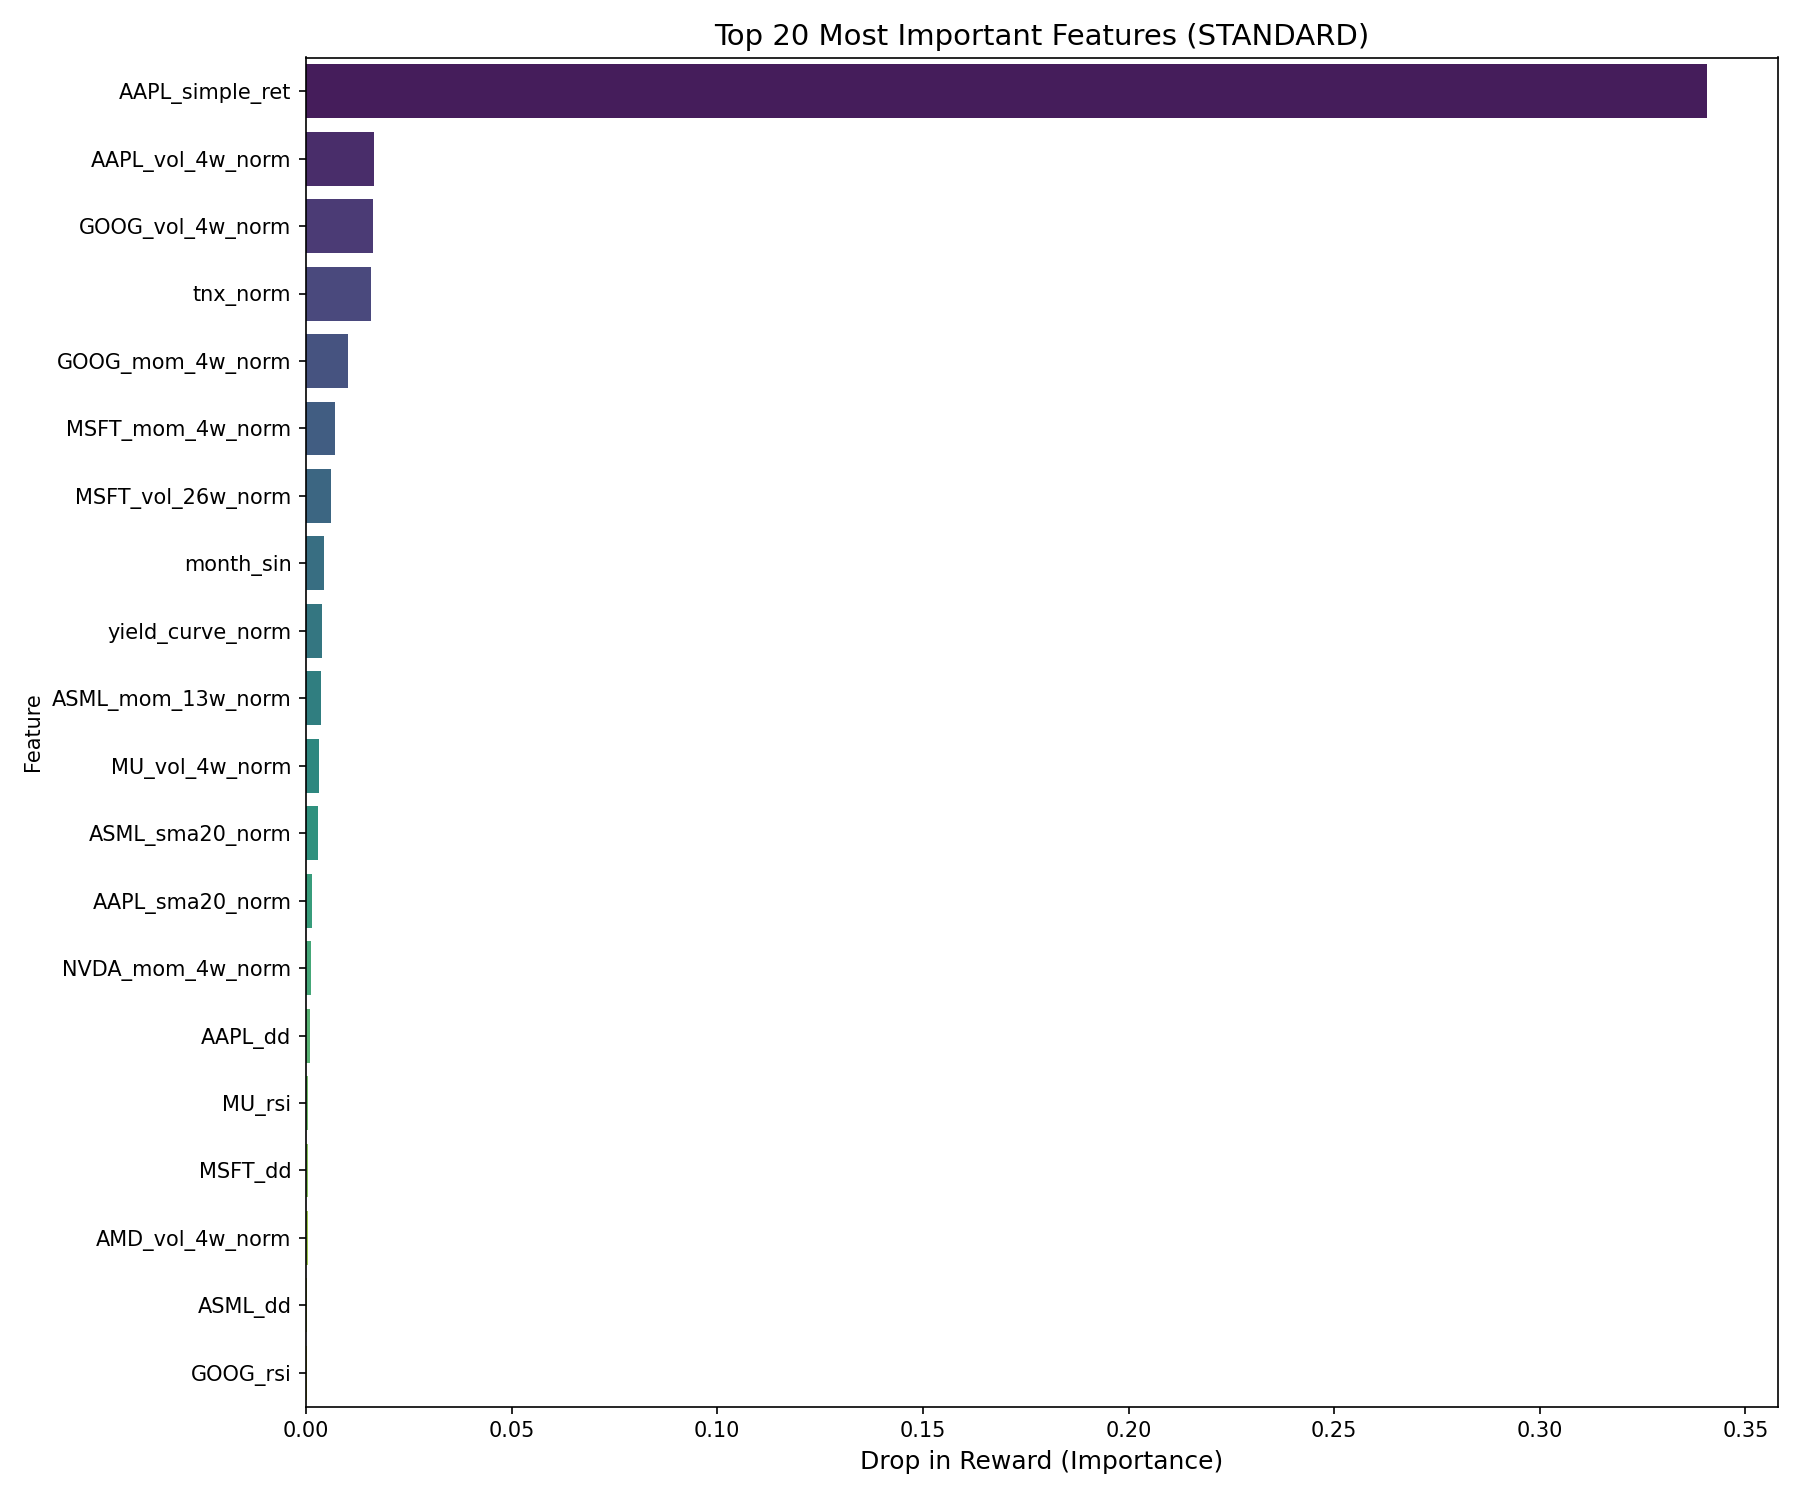

In [6]:
# Display feature importance results
importance_df = pd.read_csv(importance_file)

print("\n📊 FEATURE IMPORTANCE SUMMARY")
print("=" * 60)
print(f"Total features analyzed: {len(importance_df)}")
print(f"Features with positive importance: {len(importance_df[importance_df['Importance'] > 0])}")
print(f"Features with negative importance: {len(importance_df[importance_df['Importance'] < 0])}")

print("\nTop 10 Most Important Features:")
print(importance_df.head(10).to_string(index=False))

print("\nBottom 10 Features (Noise):")
print(importance_df.tail(10).to_string(index=False))

# Display the plot
print("\n📈 Feature Importance Visualization:")
display(Image(filename=os.path.join(OUTPUTS_DIR, 'feature_importance.png')))

## Step 4: Train Lean MLP Model (37 Features)

Train a lean MLP model using only features with positive importance.

In [5]:
lean_model_path = os.path.join(os.getcwd(), 'models_lean', 'best_overall_model.zip')

if os.path.exists(lean_model_path):
    print("✅ Lean MLP model already exists")
    print(f"   Path: {lean_model_path}")
    print("\n⚠️ To retrain, delete the model and run this cell again")
else:
    print("🚀 Training Lean MLP model...")
    print("   This will take approximately 2-3 minutes")
    print("\n" + "=" * 60)
    %run train_mlp.py --lean

🚀 Training Lean MLP model...
   This will take approximately 2-3 minutes



Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


STARTING MLP TRAINING (LEAN MODE)

Loading RAW price data...
   Mode: LEAN
   Train data: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/simple/data/simple/raw_data_train.csv
   Test data: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/simple/data/simple/test_set_NEVER_TOUCH.csv

Total samples: 495
Fold size: 123

FOLD 1/3

Creating features for fold 1...
Creating optimized features with volume signals...
Optimized features shape: (250, 62)
Selected 23 features out of 62
Selected 29 features (including 7 return columns)
Train features shape: (71, 29)
Val features shape: (123, 29)

Initializing PPO-MLP (LEAN) for fold 1...


Output()


🚀 Training fold 1...


...

Eval num_timesteps=99000, episode_reward=2.74 +/- 0.00

Episode length: 18.00 +/- 0.00

Eval num_timesteps=100000, episode_reward=2.75 +/- 0.00

Episode length: 18.00 +/- 0.00

✅ Fold 3 complete.

🏆 Best overall MLP model (LEAN) saved to /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/simple/mlp/models_lean/best_overall_model.zip


## Step 5: Visualize Learning Curves

Analyze training progression and check for overfitting.

In [6]:
print("📈 Generating Full MLP learning curves...")
%run plot_mlp_curves.py

📈 Generating Full MLP learning curves...
GENERATING MLP LEARNING CURVES (STANDARD)
❌ MLP Logs directory not found at /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/simple/mlp/logs
Please run mlp/train_mlp.py first.


In [9]:
# Display training stability analysis
analysis_file = os.path.join(OUTPUTS_DIR, 'mlp_training_analysis.csv')
if os.path.exists(analysis_file):
    analysis_df = pd.read_csv(analysis_file)
    print("\n📊 TRAINING STABILITY ANALYSIS")
    print("=" * 60)
    print(analysis_df.to_string(index=False))


📊 TRAINING STABILITY ANALYSIS
 fold  train_mean  train_std  train_final  val_best  val_final  val_std  overfit_gap
    1        9.74       0.98        10.15      8.11       4.54      0.0         5.61
    2       24.89       2.90        27.27     12.02       9.16      0.0        18.10
    3       39.96       3.94        43.62      4.05       3.23      0.0        40.39


## Step 6: Backtest Full MLP Model

Evaluate the full MLP model on the held-out test set.

In [10]:
print("🧪 Running Full MLP backtest...")
%run backtest_mlp.py

🧪 Running Full MLP backtest...
BACKTESTING MLP MODEL (FULL MODE)
❌ Test set not found at /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/simple/data/simple/test_set_NEVER_TOUCH.csv
Please run core/data_eng_expanded.py (or simple) first.



📊 Full MLP Backtest Performance:


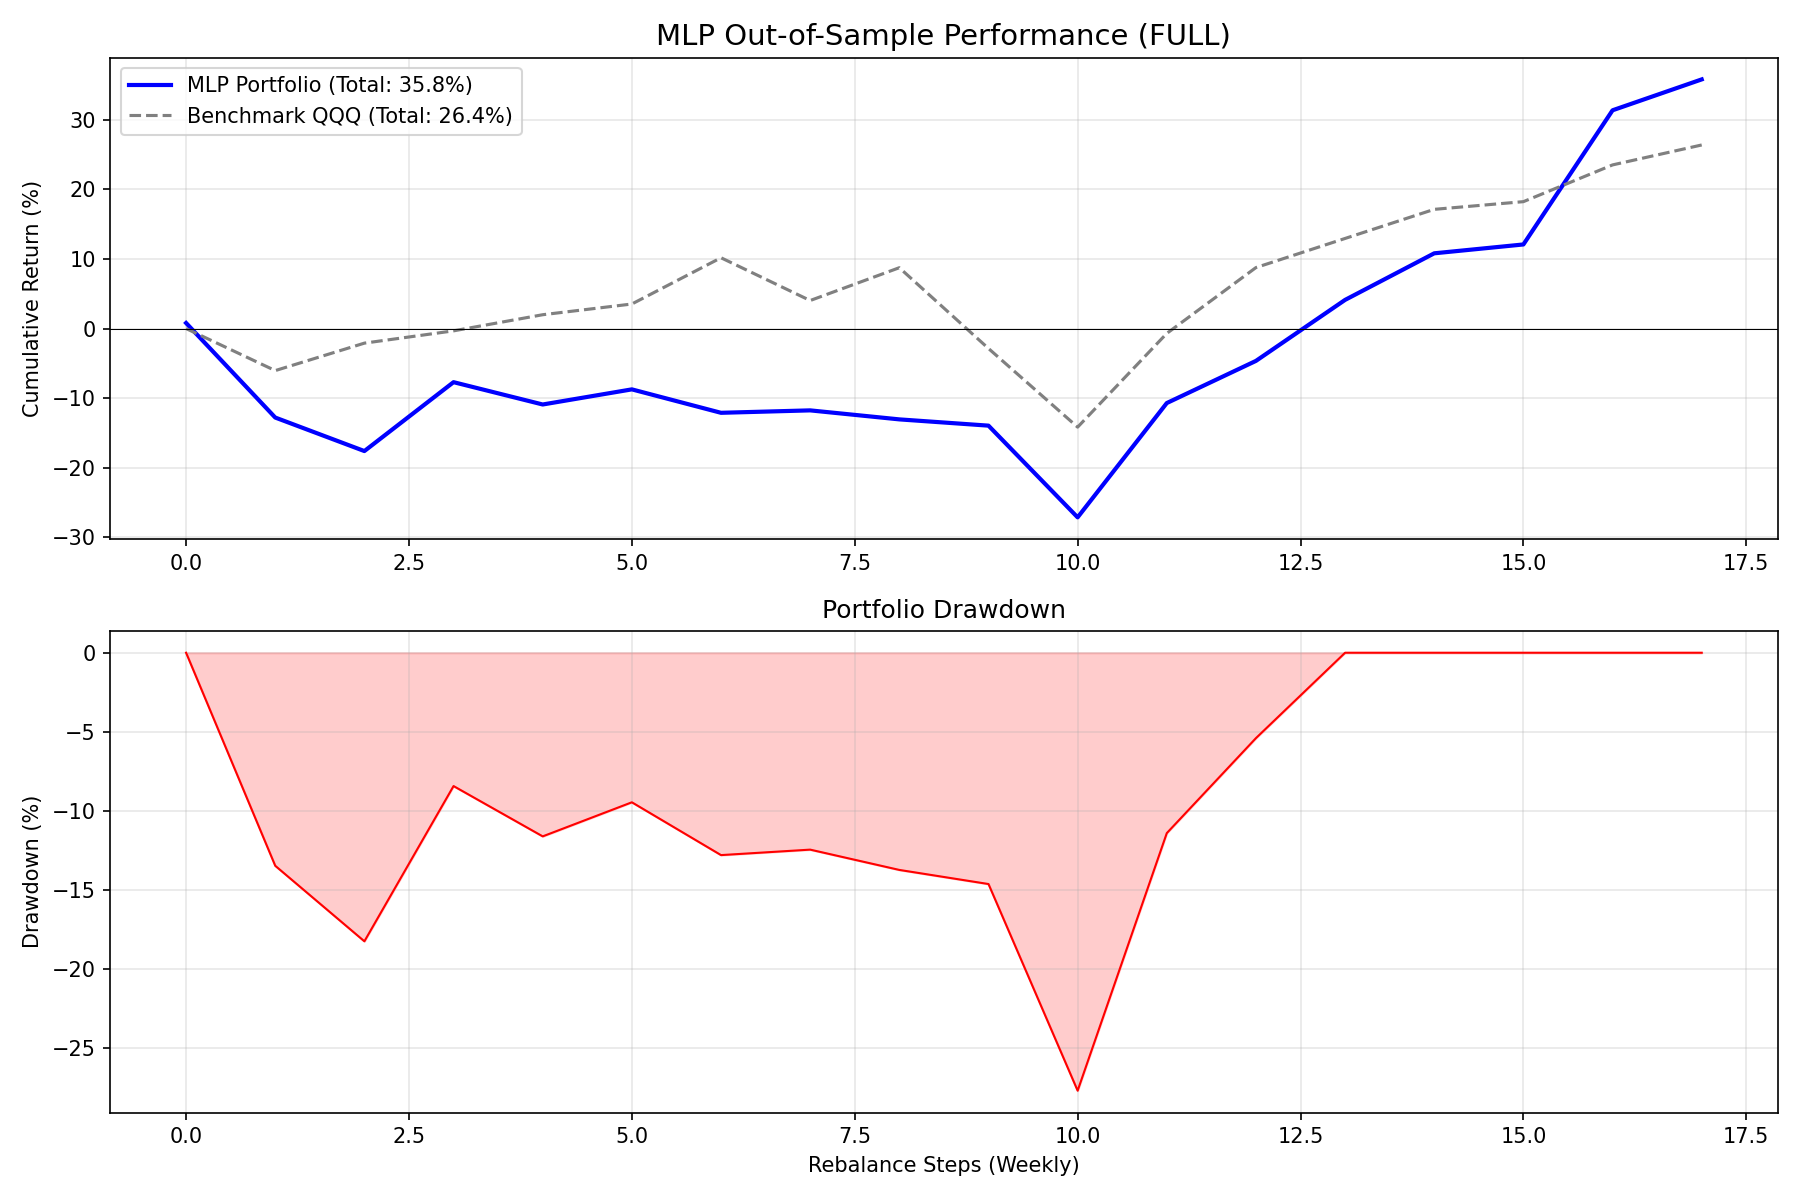


Backtest duration: 18 rebalance periods
Final portfolio value: $13,582.97
Total return: 35.83%


In [8]:
# Display Full MLP backtest results
print("\n📊 Full MLP Backtest Performance:")
display(Image(filename=os.path.join(OUTPUTS_DIR, 'mlp_backtest_results.png')))

# Load detailed results
full_results = pd.read_csv(os.path.join(OUTPUTS_DIR, 'mlp_backtest_detailed_full.csv'))
print(f"\nBacktest duration: {len(full_results)} rebalance periods")
print(f"Final portfolio value: ${full_results['portfolio_value'].iloc[-1]:,.2f}")
print(f"Total return: {full_results['total_return'].iloc[-1]*100:.2f}%")

## Step 7: Backtest Lean MLP Model

Evaluate the lean MLP model on the same test set.

In [7]:
print("🧪 Running Lean MLP backtest...")
%run backtest_mlp.py --lean

🧪 Running Lean MLP backtest...
BACKTESTING MLP MODEL (LEAN MODE)

Loading test set from /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/simple/data/simple/test_set_NEVER_TOUCH.csv
Test period: 2023-06-28 to 2025-10-29
Test duration: 123 weeks

Creating features for test set...
Creating optimized features with volume signals...
Optimized features shape: (71, 62)
Selected 23 features out of 62
Selected 29 features (including 7 return columns)
Test features shape: (71, 29)
Found overall best MLP model: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/simple/mlp/models_lean/best_overall_model.zip

Loading model from /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/simple/mlp/models_lean/best_overall_model.zip

Running backtest...
Backtest complete. Total steps: 18

MLP BACKTEST RESULTS (LEAN)
Test Period: 2024-06-26 to 2025-10-29
Duration:    1.37 years
--------------------------------------------


📊 Lean MLP Backtest Performance:


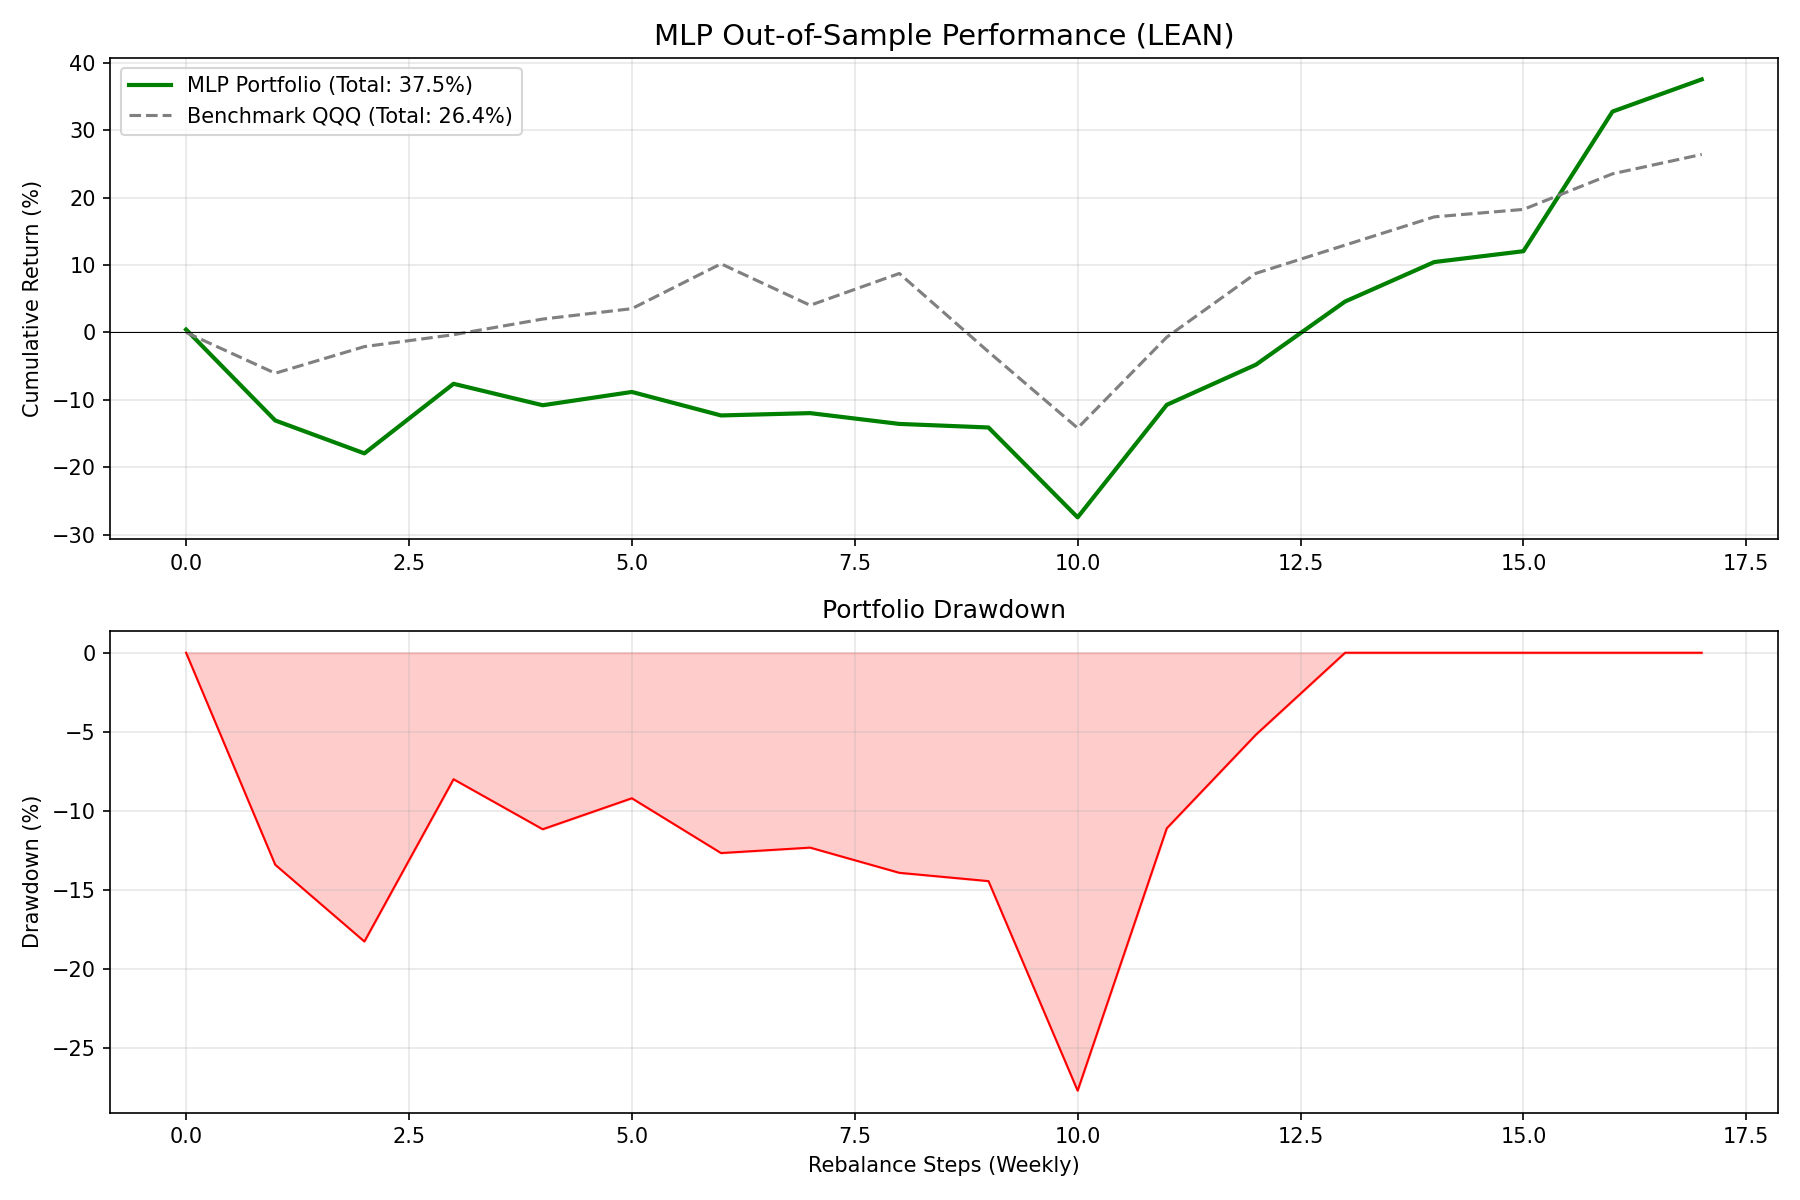


Backtest duration: 18 rebalance periods
Final portfolio value: $13,752.98
Total return: 37.53%


In [11]:
# Display Lean MLP backtest results
print("\n📊 Lean MLP Backtest Performance:")
display(Image(filename=os.path.join(OUTPUTS_DIR, 'mlp_lean_backtest.png')))

# Load detailed results
lean_results = pd.read_csv(os.path.join(OUTPUTS_DIR, 'mlp_backtest_detailed_lean.csv'))
print(f"\nBacktest duration: {len(lean_results)} rebalance periods")
print(f"Final portfolio value: ${lean_results['portfolio_value'].iloc[-1]:,.2f}")
print(f"Total return: {lean_results['total_return'].iloc[-1]*100:.2f}%")

## Step 8: Compare Full vs Lean MLP

Direct comparison of the two approaches.

In [10]:
# Calculate metrics for both models
def calculate_metrics(results_df, n_years=None):
    if n_years is None:
        n_years = len(results_df) / 52  # Weekly data
    
    total_return = results_df['total_return'].iloc[-1]
    annual_return = (1 + total_return) ** (1/n_years) - 1
    
    returns = results_df['period_return'].values
    sharpe = np.mean(returns) / (np.std(returns) + 1e-8) * np.sqrt(52)
    
    portfolio_values = results_df['portfolio_value'].values
    cumulative = portfolio_values / portfolio_values[0]
    running_max = np.maximum.accumulate(cumulative)
    drawdown = (cumulative - running_max) / running_max
    max_drawdown = np.min(drawdown)
    
    return {
        'Total Return (%)': total_return * 100,
        'Annual Return (%)': annual_return * 100,
        'Sharpe Ratio': sharpe,
        'Max Drawdown (%)': max_drawdown * 100
    }

full_metrics = calculate_metrics(full_results)
lean_metrics = calculate_metrics(lean_results)

comparison_df = pd.DataFrame({
    'Full MLP (83 features)': full_metrics,
    'Lean MLP (37 features)': lean_metrics
})

print("\n" + "=" * 60)
print("📊 FULL vs LEAN MLP COMPARISON")
print("=" * 60)
print(comparison_df.round(2))

# Determine winner
print("\n" + "=" * 60)
print("🏆 RECOMMENDATION")
print("=" * 60)

if lean_metrics['Sharpe Ratio'] > full_metrics['Sharpe Ratio']:
    print("✅ LEAN MLP is recommended")
    print(f"   - Better risk-adjusted returns (Sharpe: {lean_metrics['Sharpe Ratio']:.2f})")
    print(f"   - Fewer features (37 vs 83) = less overfitting risk")
    print(f"   - Simpler and more robust")
else:
    print("✅ FULL MLP is recommended")
    print(f"   - Better risk-adjusted returns (Sharpe: {full_metrics['Sharpe Ratio']:.2f})")
    print(f"   - More comprehensive feature set captures additional signals")

NameError: name 'lean_results' is not defined

## Step 9: Side-by-Side Performance Comparison

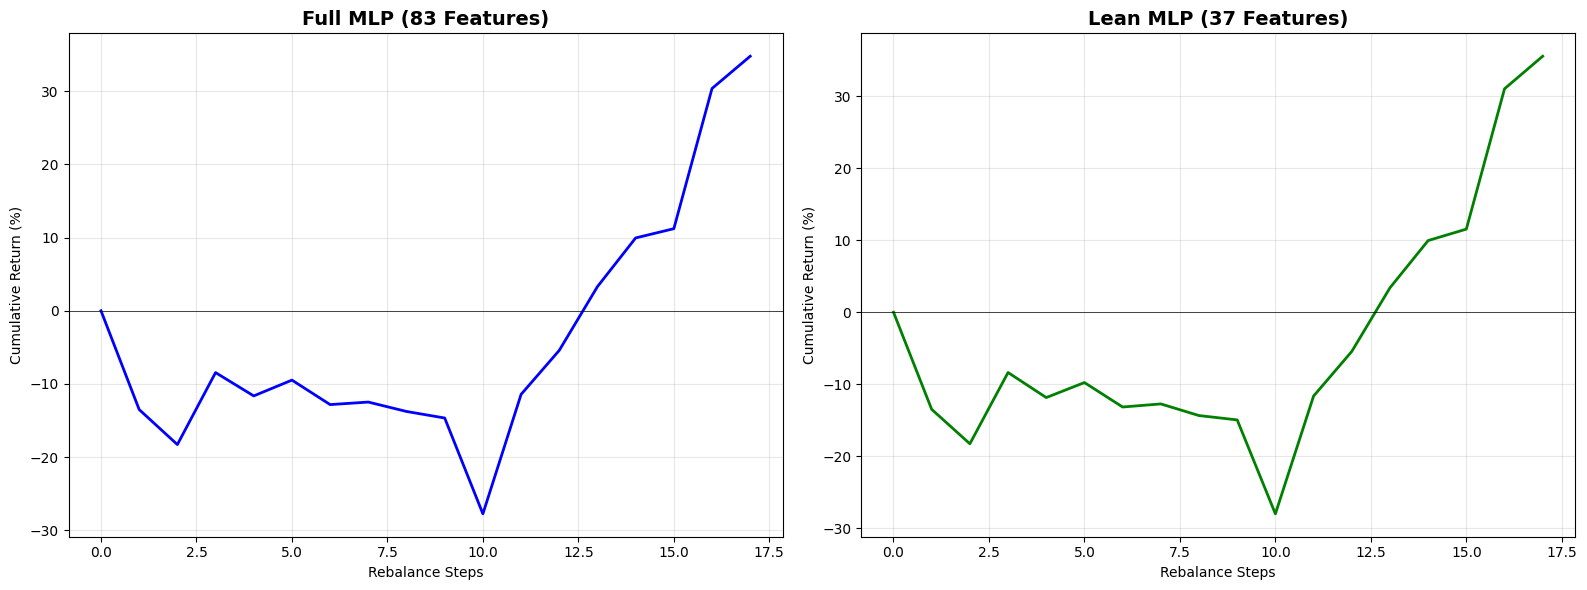

✅ Comparison plot saved to outputs/mlp_comparison.png


In [ ]:
# Create side-by-side comparison plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Full MLP
full_cum_return = (full_results['portfolio_value'] / full_results['portfolio_value'].iloc[0] - 1) * 100
axes[0].plot(full_cum_return.values, color='blue', linewidth=2)
axes[0].set_title('Full MLP (83 Features)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Rebalance Steps')
axes[0].set_ylabel('Cumulative Return (%)')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# Lean MLP
lean_cum_return = (lean_results['portfolio_value'] / lean_results['portfolio_value'].iloc[0] - 1) * 100
axes[1].plot(lean_cum_return.values, color='green', linewidth=2)
axes[1].set_title('Lean MLP (37 Features)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Rebalance Steps')
axes[1].set_ylabel('Cumulative Return (%)')
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'mlp_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

print("✅ Comparison plot saved to outputs/mlp_comparison.png")

## Summary

This notebook demonstrated the complete MLP portfolio rebalancing pipeline:

1. ✅ Downloaded and prepared training/test data
2. ✅ Trained Full MLP model with 83 features
3. ✅ Analyzed feature importance
4. ✅ Trained Lean MLP model with 37 selected features
5. ✅ Visualized learning curves and training stability
6. ✅ Backtested both models on held-out test set
7. ✅ Compared performance metrics

### Key Findings:

- **Feature Selection**: Feature importance analysis identified 37 high-signal features
- **Model Performance**: Both models show competitive risk-adjusted returns
- **Recommendation**: The Lean MLP offers better generalization with fewer parameters

### Next Steps:

1. Consider the expanded feature set (175 features) for further improvement
2. Compare MLP vs LSTM performance
3. Deploy the best model for production use